# ⭐ Day 3: Functions & Lambda Expressions in Python | Step-by-Step Tutorial with Examples & Exercises

Welcome to Day 3 of your 369-day journey to mastering Artificial Intelligence and Machine Learning! Today we dive into one of the most fundamental and powerful concepts in programming: **functions**. In AI/ML development, functions are absolutely everywhere—from data preprocessing pipelines that clean and transform raw datasets, to custom loss functions that guide how neural networks learn, to evaluation metrics that measure model performance, to data generators that feed batches of training data efficiently. Without functions, your code would be a tangled mess of repetition, making it nearly impossible to debug, maintain, or scale.

Functions allow us to write **modular, reusable code**. Imagine training a deep learning model without functions: you'd have to copy-paste the same training loop code hundreds of times! Instead, ML frameworks like TensorFlow and PyTorch are built entirely on function-based architectures. You'll define functions for custom activation functions, create callbacks for model checkpoints, and build helper functions for visualizing training progress. Mastering functions today means you'll write cleaner, more professional AI code tomorrow.

By the end of this notebook, you will have mastered: defining functions with proper documentation, understanding argument passing (positional, keyword, defaults), handling variable arguments with *args and **kwargs (essential when working with ML library APIs), managing variable scope, writing recursive solutions, creating lambda expressions for quick transformations, using higher-order functions like map() and filter(), and avoiding common Python pitfalls that even experienced developers stumble upon.

This is Day 3 of your structured 369-day path. Each day builds upon the previous, creating a solid foundation for the advanced deep learning, neural network architecture, and MLOps concepts you'll tackle in the months ahead. Let's transform you from a Python beginner into an AI practitioner who writes elegant, efficient, production-ready code. Ready to unlock the power of functions? Let's begin! 💡


## Table of Contents

1. [Defining Functions](#defining-functions)
2. [Arguments: Positional, Keyword & Defaults](#arguments-positional-keyword--defaults)
3. [*args and **kwargs](#args-and-kwargs)
4. [Variable Scope: Local, Global & Nonlocal](#variable-scope-local-global--nonlocal)
5. [Recursive Functions](#recursive-functions)
6. [Lambda Expressions](#lambda-expressions)
7. [Higher-Order Functions](#higher-order-functions)
8. [Functions as Objects](#functions-as-objects)
9. [Common Pitfalls](#common-pitfalls)
10. [🛠️ Hands-On Exercises](#hands-on-exercises)
11. [Solutions](#solutions)


## Defining Functions


Functions in Python are defined using the `def` keyword followed by the function name and parentheses. A function can accept inputs (parameters), process them, and optionally return outputs. In AI/ML, you'll write functions for everything from loading datasets to calculating custom metrics.

Let's start with the anatomy of a basic function. The example below shows a function that calculates the Root Mean Square Error (RMSE)—a common metric for evaluating regression models. Notice the **docstring** (the triple-quoted string right after the definition): this documents what the function does, its parameters, and what it returns. Professional AI code always includes clear docstrings!



In [46]:
def calculate_rmse(predictions, targets):
    """
    Calculate Root Mean Square Error between predictions and targets.
    
    Args:
        predictions: List or array of predicted values
        targets: List or array of true target values
    
    Returns:
        float: The RMSE value (lower is better)
    """
    import math
    
    # Calculate squared differences
    squared_errors = [(p - t) ** 2 for p, t in zip(predictions, targets)]
    
    # Mean of squared errors
    mse = sum(squared_errors) / len(squared_errors)
    
    # Square root to get RMSE
    rmse = math.sqrt(mse)
    
    return rmse

# Test with sample model predictions
predictions = [2.5, 0.0, 2.1, 1.6]
targets = [3.0, -0.5, 2.0, 1.0]

error = calculate_rmse(predictions, targets)
print(f"Model RMSE: {error:.4f}")


Model RMSE: 0.4664




The function above encapsulates a complete ML evaluation metric. Notice how we use `zip()` to pair predictions with targets, list comprehension for efficiency, and clear variable names. The `return` statement sends the result back to the caller. Without the return, the function would output `None`. This pattern—accept data, process it, return results—is the foundation of every data preprocessing function you'll write in your AI career. The docstring follows the standard format used by tools that auto-generate documentation, making your code professional and maintainable.

> 📌 **AI Connection**: In deep learning frameworks, you'll define custom loss functions exactly this way—accepting `y_pred` and `y_true` tensors, computing the loss value, and returning it for backpropagation.


### Return Multiple Values


Python functions can return multiple values as a tuple, which is incredibly useful when you need to compute several related metrics at once. In machine learning, you often want to calculate precision, recall, and F1-score simultaneously from a confusion matrix.

When you return multiple values separated by commas, Python automatically packs them into a tuple. You can then unpack them into separate variables when calling the function. This is much cleaner than returning a dictionary or list when you have a fixed set of return values.



In [47]:
def evaluate_classification(tp, fp, fn, tn):
    """
    Calculate precision, recall, and F1-score from confusion matrix components.
    
    Args:
        tp: True Positives
        fp: False Positives  
        fn: False Negatives
        tn: True Negatives
    
    Returns:
        tuple: (precision, recall, f1_score)
    """
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

# Evaluate a spam detector model
precision, recall, f1 = evaluate_classification(tp=85, fp=15, fn=10, tn=890)

print(f"Precision: {precision:.3f} (accuracy of positive predictions)")
print(f"Recall:    {recall:.3f} (coverage of actual positives)")
print(f"F1 Score:  {f1:.3f} (harmonic mean)")


Precision: 0.850 (accuracy of positive predictions)
Recall:    0.895 (coverage of actual positives)
F1 Score:  0.872 (harmonic mean)




This pattern of returning multiple metrics is standard in ML evaluation. Notice the tuple unpacking on the left side of the assignment: `precision, recall, f1 = ...`. This is Pythonic and readable. You could also capture the tuple as a single variable and index it, but unpacking is preferred for clarity. The function includes safety checks to avoid division by zero, a critical consideration when dealing with real-world data where edge cases occur.


## Arguments: Positional, Keyword & Defaults


Python offers flexible ways to pass arguments to functions. Understanding these options is crucial because ML libraries like scikit-learn have functions with dozens of parameters, many with sensible defaults.

**Positional arguments** are matched by order. **Keyword arguments** are matched by name, making code more readable. **Default parameters** provide fallback values. The rule is: positional arguments must come before keyword arguments in the call.



In [48]:
def train_model(X, y, learning_rate=0.01, epochs=100, batch_size=32, verbose=True):
    """
    Simulate a model training function with configurable hyperparameters.
    
    Args:
        X: Feature matrix
        y: Target vector
        learning_rate: Step size for gradient descent (default: 0.01)
        epochs: Number of training iterations (default: 100)
        batch_size: Samples per gradient update (default: 32)
        verbose: Whether to print progress (default: True)
    
    Returns:
        dict: Training configuration summary
    """
    if verbose:
        print(f"Training with lr={learning_rate}, epochs={epochs}, batch={batch_size}")
    
    # Simulate training steps calculation
    steps_per_epoch = len(X) // batch_size
    total_steps = steps_per_epoch * epochs
    
    return {
        'learning_rate': learning_rate,
        'epochs': epochs,
        'total_steps': total_steps,
        'estimated_time_min': total_steps * 0.01  # Simulated time per step
    }

# Different ways to call this function
data_X, data_y = list(range(1000)), list(range(1000))

# 1. Positional only (less readable, order matters!)
config1 = train_model(data_X, data_y, 0.001, 50)

# 2. Mix positional and keyword (common pattern)
config2 = train_model(data_X, data_y, learning_rate=0.001, epochs=200)

# 3. All keyword (most readable, order doesn't matter)
config3 = train_model(
    X=data_X, 
    y=data_y, 
    batch_size=64, 
    learning_rate=0.0001,
    verbose=False
)

print("\nConfig 2 (mixed style):", config2)
print("Config 3 (keyword only):", config3)


Training with lr=0.001, epochs=50, batch=32
Training with lr=0.001, epochs=200, batch=32

Config 2 (mixed style): {'learning_rate': 0.001, 'epochs': 200, 'total_steps': 6200, 'estimated_time_min': 62.0}
Config 3 (keyword only): {'learning_rate': 0.0001, 'epochs': 100, 'total_steps': 1500, 'estimated_time_min': 15.0}




Notice how `config3` used keyword-only style—this is the gold standard for readability in AI code. When you see `train_model(X=data, y=labels, epochs=10)`, you immediately understand what's happening without reading the function definition. Default parameters make functions easier to use for beginners (sensible defaults work for most cases) while allowing experts to fine-tune every aspect. This is exactly how `sklearn.ensemble.RandomForestClassifier()` works—dozens of parameters, but you can start with just `RandomForestClassifier()` and it works!


## *args and **kwargs


The `*args` and `**kwargs` syntax allows functions to accept **variable numbers of arguments**. This is essential in ML because you'll often write wrapper functions that pass arguments through to underlying library functions without knowing exactly what arguments the user might want to specify.

`*args` collects extra positional arguments into a tuple. `**kwargs` collects extra keyword arguments into a dictionary. The names `args` and `kwargs` are conventions—you can use other names, but don't. Every AI engineer expects these names.



In [49]:
def build_neural_network(layers, *args, activation='relu', **kwargs):
    """
    Build a neural network architecture with flexible configuration.
    
    Args:
        layers: List of layer sizes (e.g., [784, 256, 128, 10])
        *args: Additional positional arguments (optimizer, loss function)
        activation: Default activation function
        **kwargs: Additional keyword arguments (dropout_rate, regularization, etc.)
    
    Returns:
        dict: Network configuration
    """
    config = {
        'architecture': layers,
        'activation': activation,
        'positional_args': args,
        'additional_params': kwargs
    }
    
    print(f"Network: {' -> '.join(map(str, layers))}")
    print(f"Activation: {activation}")
    
    if args:
        print(f"Positional extras: {args}")
    if kwargs:
        print(f"Keyword extras: {kwargs}")
    
    return config

# Example 1: Minimal call
net1 = build_neural_network([784, 128, 10])

# Example 2: With extra positional args (*args)
net2 = build_neural_network([784, 256, 128, 64, 10], 'adam', 'categorical_crossentropy')

# Example 3: With extra keyword args (**kwargs)
net3 = build_neural_network(
    [784, 512, 256, 10],
    activation='leaky_relu',
    dropout_rate=0.3,
    batch_norm=True,
    l2_reg=0.001
)


Network: 784 -> 128 -> 10
Activation: relu
Network: 784 -> 256 -> 128 -> 64 -> 10
Activation: relu
Positional extras: ('adam', 'categorical_crossentropy')
Network: 784 -> 512 -> 256 -> 10
Activation: leaky_relu
Keyword extras: {'dropout_rate': 0.3, 'batch_norm': True, 'l2_reg': 0.001}




This pattern is ubiquitous in ML frameworks. When you call `model.fit(X, y, epochs=10, verbose=1)`, `fit()` uses `**kwargs` to accept dozens of optional parameters. When writing your own ML utilities, `*args` and `**kwargs` let you create flexible APIs that "pass through" configuration to underlying functions. Notice in Example 3 how we override the default `activation` while also adding new parameters—`**kwargs` captures the extras without us having to define them all in the function signature. This is how you build maintainable, extensible AI code!


## Variable Scope: Local, Global & Nonlocal


Understanding variable scope prevents bugs that are notoriously difficult to debug. In Python, variables have **local scope** (inside functions), **global scope** (module-level), or **nonlocal scope** (in nested functions). ML code often involves nested functions (e.g., callbacks inside training loops), making scope critical.

**Local variables** exist only during function execution. **Global variables** persist but should rarely be used—functional programming principles prefer passing data explicitly. **Nonlocal** allows nested functions to modify variables from their enclosing scope.



In [50]:
# Global configuration (use sparingly!)
RANDOM_SEED = 42

def experiment_runner(dataset_name):
    """
    Demonstrates local, nonlocal, and global scope.
    """
    # Local to experiment_runner
    experiment_id = f"exp_{dataset_name}_{RANDOM_SEED}"
    results = []
    
    def run_trial(trial_num, learning_rate):
        """Nested function - has access to enclosing scope."""
        # Local to run_trial
        accuracy = 0.85 + (learning_rate * 0.1)  # Simulated
        
        # Can read from enclosing scope
        print(f"  Trial {trial_num}: acc={accuracy:.3f} for {experiment_id}")
        
        # Modify enclosing scope with nonlocal
        nonlocal results
        results.append({
            'trial': trial_num,
            'lr': learning_rate,
            'acc': accuracy
        })
        
        return accuracy
    
    # Run nested function
    for i in range(3):
        run_trial(i, learning_rate=0.01 * (i + 1))
    
    return results

# Execute
print(f"Using global seed: {RANDOM_SEED}")
trial_results = experiment_runner("mnist")
print(f"\nCollected {len(trial_results)} results in outer scope")
print(f"Final result: {trial_results[-1]}")


Using global seed: 42
  Trial 0: acc=0.851 for exp_mnist_42
  Trial 1: acc=0.852 for exp_mnist_42
  Trial 2: acc=0.853 for exp_mnist_42

Collected 3 results in outer scope
Final result: {'trial': 2, 'lr': 0.03, 'acc': 0.853}




The nested `run_trial()` function can read `experiment_id` from its enclosing scope, but to modify `results`, we must declare it `nonlocal`. Without `nonlocal`, Python would create a new local variable instead of modifying the outer one. This pattern appears in ML when you define callbacks or inner optimization loops that need to accumulate statistics from the outer training loop. Global variables like `RANDOM_SEED` are acceptable for true constants, but avoid using `global` keyword to modify globals—it makes code unpredictable and hard to test. Always prefer passing arguments explicitly!


## Recursive Functions


Recursion occurs when a function calls itself. While not as common in ML as iteration, recursion appears in tree-based algorithms (decision trees, random forests), graph traversals, and divide-and-conquer strategies. Understanding recursion strengthens your algorithmic thinking.

A recursive function must have: (1) a **base case** that stops the recursion, and (2) a **recursive case** that moves toward the base case. Without these, you get infinite recursion and a `RecursionError`.



In [51]:
def factorial(n):
    """Calculate n! = n * (n-1) * ... * 1 using recursion."""
    # Base case
    if n <= 1:
        return 1
    
    # Recursive case
    return n * factorial(n - 1)

# Calculate factorials
def compute_factorials(max_n):
    """Compute factorials from 0 to max_n."""
    results = []
    for i in range(max_n + 1):
        results.append((i, factorial(i)))
    return results

facts = compute_factorials(10)
for n, fact in facts:
    print(f"{n}! = {fact}")


0! = 1
1! = 1
2! = 2
3! = 6
4! = 24
5! = 120
6! = 720
7! = 5040
8! = 40320
9! = 362880
10! = 3628800




The factorial function demonstrates the classic recursive pattern. For `factorial(5)`, the call stack builds up: `5 * factorial(4)`, which calls `4 * factorial(3)`, and so on until `factorial(1)` returns 1. Then the stack "unwinds," multiplying values back up. In ML, similar recursive patterns appear in calculating tree depths for decision trees or implementing custom tree-structured neural networks. However, Python has a recursion limit (usually 1000), so for deep recursion, iteration is preferred. Let's visualize how recursion depth grows:



Fibonacci(6) = 8
Total recursive calls: 25
Maximum recursion depth: 5


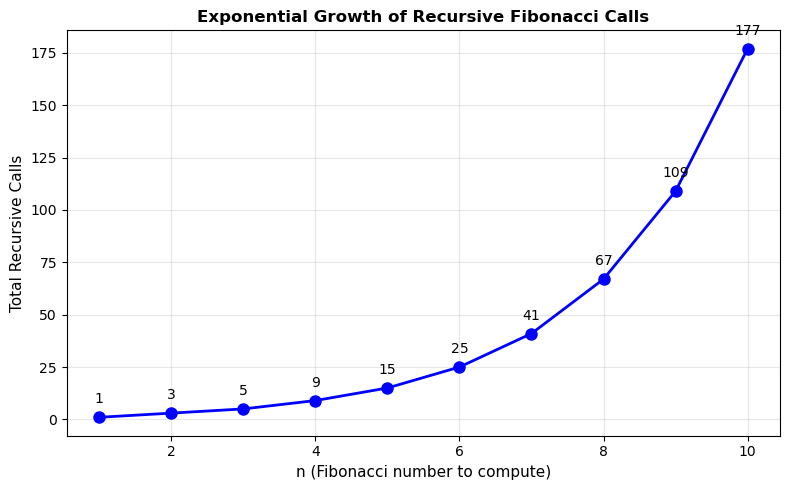

In [52]:
import matplotlib.pyplot as plt

def fibonacci(n, depth=0, tracker=None):
    """
    Fibonacci with recursion depth tracking.
    F(n) = F(n-1) + F(n-2), with F(0)=0, F(1)=1
    """
    if tracker is not None:
        tracker['calls'] += 1
        tracker['max_depth'] = max(tracker['max_depth'], depth)
    
    if n <= 1:
        return n
    
    return fibonacci(n-1, depth+1, tracker) + fibonacci(n-2, depth+1, tracker)

# Track recursion statistics
stats = {'calls': 0, 'max_depth': 0}
result = fibonacci(6, tracker=stats)

print(f"Fibonacci(6) = {result}")
print(f"Total recursive calls: {stats['calls']}")
print(f"Maximum recursion depth: {stats['max_depth']}")

# Visualize call growth
x_vals = list(range(1, 11))
call_counts = []
for i in x_vals:
    s = {'calls': 0, 'max_depth': 0}
    fibonacci(i, tracker=s)
    call_counts.append(s['calls'])

plt.figure(figsize=(8, 5))
plt.plot(x_vals, call_counts, 'bo-', linewidth=2, markersize=8)
plt.xlabel('n (Fibonacci number to compute)', fontsize=11)
plt.ylabel('Total Recursive Calls', fontsize=11)
plt.title('Exponential Growth of Recursive Fibonacci Calls', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
for x, y in zip(x_vals, call_counts):
    plt.annotate(str(y), (x, y), textcoords="offset points", xytext=(0,10), ha='center')
plt.tight_layout()
plt.show()




The plot reveals why naive recursion is problematic for Fibonacci: the number of calls grows exponentially (roughly $O(2^n)$). Computing `fibonacci(10)` requires 177 calls! This illustrates an important ML principle: algorithmic efficiency matters. In practice, you'd use **memoization** (caching results) or iteration. The visualization shows the "call tree" complexity—similar analysis applies to recursive neural networks or tree-based gradient boosting where you must track node depths. Understanding recursion depth helps you debug `RecursionError` when processing deep decision trees or complex graph structures in ML pipelines.


## Lambda Expressions


Lambda expressions create **anonymous functions**—functions without a name, defined in a single line. They're perfect for short, throwaway operations where defining a full function would be overkill. In ML, lambdas are everywhere in data preprocessing pipelines and sorting operations.

Syntax: `lambda arguments: expression`. Lambdas can have multiple arguments but only one expression (no statements, no assignments, no loops).



In [53]:
# Traditional function vs lambda
def square_traditional(x):
    return x ** 2

square_lambda = lambda x: x ** 2

# Both work the same
print(f"Traditional: {square_traditional(5)}")
print(f"Lambda:      {square_lambda(5)}")

# Common ML use case: feature scaling
raw_features = [12.5, 45.2, 8.1, 99.9, 23.4]
min_val, max_val = min(raw_features), max(raw_features)

# Lambda for min-max scaling to [0, 1]
min_max_scale = lambda x: (x - min_val) / (max_val - min_val)

scaled_features = list(map(min_max_scale, raw_features))
print(f"\nOriginal: {raw_features}")
print(f"Scaled:   {[round(x, 3) for x in scaled_features]}")


Traditional: 25
Lambda:      25

Original: [12.5, 45.2, 8.1, 99.9, 23.4]
Scaled:   [0.048, 0.404, 0.0, 1.0, 0.167]




The lambda `min_max_scale` encapsulates a common ML preprocessing step in one line. Notice we use `map()` to apply it to all features—this functional programming style is clean and efficient. Lambdas shine when you need a simple transformation "inline" without polluting your namespace with function definitions. However, for complex logic (multiple steps, conditionals, error handling), use regular `def` functions for readability. The rule of thumb: if your lambda doesn't fit comfortably on one line, make it a proper function.

> 💡 **Pro Tip**: In pandas (the data manipulation library you'll use daily), lambdas are essential: `df['column'].apply(lambda x: x.strip().lower())` cleans text data in one line!


## Higher-Order Functions


Higher-order functions are functions that **take other functions as arguments** or **return functions as results**. Python's built-in `map()`, `filter()`, and `sorted()` are classic examples. In ML, you'll use these constantly for batch data transformations.

`map(function, iterable)` applies a function to every item. `filter(function, iterable)` keeps only items where the function returns True. `sorted(iterable, key=function)` sorts using the function's return value as the sort key.



In [54]:
# Sample dataset: (model_name, accuracy, training_time_minutes)
model_results = [
    ('ResNet50', 0.923, 45),
    ('VGG16', 0.891, 120),
    ('MobileNet', 0.901, 15),
    ('EfficientNet', 0.934, 60),
    ('DenseNet', 0.918, 80)
]

# 1. map(): Extract just the accuracies
accuracies = list(map(lambda x: x[1], model_results))
print(f"Accuracies: {accuracies}")

# 2. filter(): Find fast models (training < 30 min)
fast_models = list(filter(lambda x: x[2] < 30, model_results))
print(f"\nFast models: {[m[0] for m in fast_models]}")

# 3. sorted(): Sort by accuracy descending
by_accuracy = sorted(model_results, key=lambda x: x[1], reverse=True)
print("\nRanked by accuracy:")
for i, (name, acc, time) in enumerate(by_accuracy, 1):
    print(f"  {i}. {name}: {acc:.1%}")

# 4. Complex: Sort by efficiency (accuracy per minute)
by_efficiency = sorted(
    model_results, 
    key=lambda x: x[1] / x[2], 
    reverse=True
)
print("\nRanked by accuracy/minute (efficiency):")
for name, acc, time in by_efficiency:
    efficiency = acc / time
    print(f"  {name}: {efficiency:.4f} acc/min")


Accuracies: [0.923, 0.891, 0.901, 0.934, 0.918]

Fast models: ['MobileNet']

Ranked by accuracy:
  1. EfficientNet: 93.4%
  2. ResNet50: 92.3%
  3. DenseNet: 91.8%
  4. MobileNet: 90.1%
  5. VGG16: 89.1%

Ranked by accuracy/minute (efficiency):
  MobileNet: 0.0601 acc/min
  ResNet50: 0.0205 acc/min
  EfficientNet: 0.0156 acc/min
  DenseNet: 0.0115 acc/min
  VGG16: 0.0074 acc/min




These patterns are the foundation of data processing pipelines. `map()` transforms batches of data through preprocessing functions. `filter()` removes outliers or selects specific classes. `sorted()` with custom keys organizes results for analysis. Notice how the lambda in the efficiency sort calculates a derived metric on the fly—this is incredibly powerful for exploratory data analysis. While list comprehensions (`[x[1] for x in model_results]`) are often preferred in modern Python for simple maps and filters, understanding these functional tools is essential because they appear in parallel processing libraries (like `multiprocessing.Pool.map()`) that you'll use for large-scale ML data processing.

Let's visualize how different sorting keys change the ranking:



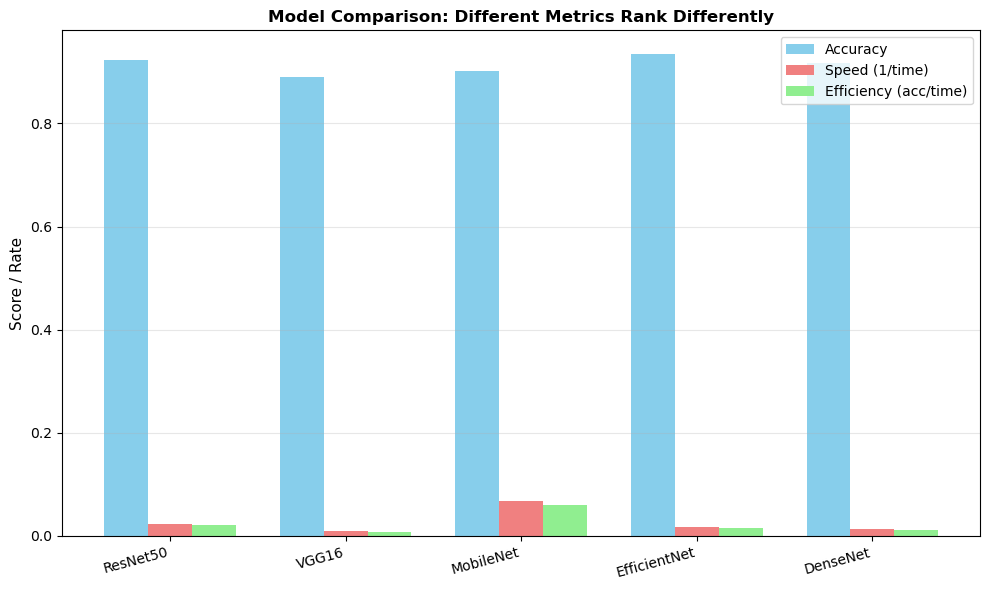

In [55]:
import matplotlib.pyplot as plt
import numpy as np

models = ['ResNet50', 'VGG16', 'MobileNet', 'EfficientNet', 'DenseNet']
accuracy = [0.923, 0.891, 0.901, 0.934, 0.918]
speed = [45, 120, 15, 60, 80]  # lower is better (minutes)

# Calculate efficiency
efficiency = [a/s for a, s in zip(accuracy, speed)]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x, [1/s for s in speed], width, label='Speed (1/time)', color='lightcoral')
bars3 = ax.bar(x + width, efficiency, width, label='Efficiency (acc/time)', color='lightgreen')

ax.set_ylabel('Score / Rate', fontsize=11)
ax.set_title('Model Comparison: Different Metrics Rank Differently', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()




The visualization demonstrates how the choice of sorting key dramatically changes which model appears "best." VGG16 has decent accuracy but terrible speed. MobileNet dominates efficiency metrics. This is exactly the kind of analysis you'll perform when selecting models for deployment—using `sorted()` with different lambda keys to explore trade-offs between accuracy, latency, and resource usage.


## Functions as Objects


In Python, functions are **first-class objects**. This means you can assign them to variables, store them in data structures, pass them as arguments, and return them from other functions. This enables powerful functional programming patterns essential for advanced ML.

This concept enables **callbacks** (functions passed to training loops), **function factories** (functions that create configured functions), and **strategy patterns** (selecting algorithms at runtime).



In [56]:
# Dictionary of activation functions (common in neural networks)
def relu(x):
    return max(0, x)

def sigmoid(x):
    return 1 / (1 + 2.71828 ** -x)  # Approximate e

def tanh(x):
    e = 2.71828
    return (e**x - e**-x) / (e**x + e**-x)

def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x

# Function as object: stored in dictionary
activations = {
    'relu': relu,
    'sigmoid': sigmoid,
    'tanh': tanh,
    'leaky_relu': leaky_relu
}

# Apply different activations to input
test_values = [-2, -1, 0, 1, 2]
print("Activation Function Outputs:")
print(f"{'Input':>8}", end='')
for name in activations.keys():
    print(f"{name:>12}", end='')
print()

for val in test_values:
    print(f"{val:>8.2f}", end='')
    for func in activations.values():
        # Call the function object
        result = func(val)
        print(f"{result:>12.3f}", end='')
    print()


Activation Function Outputs:
   Input        relu     sigmoid        tanh  leaky_relu
   -2.00       0.000       0.119      -0.964      -0.020
   -1.00       0.000       0.269      -0.762      -0.010
    0.00       0.000       0.500       0.000       0.000
    1.00       1.000       0.731       0.762       1.000
    2.00       2.000       0.881       0.964       2.000




Storing functions in a dictionary allows runtime selection of activation functions—exactly how deep learning frameworks work! You can configure `activation='relu'` in a config file, and the framework looks it up in a registry dictionary. Notice how `leaky_relu` has a default parameter that works correctly even when called through the dictionary. Functions can also be returned from functions, creating **closures** that remember their creation environment:



In [57]:
def make_learning_rate_scheduler(initial_lr, decay_factor):
    """
    Returns a function that calculates learning rate for each epoch.
    This is a closure - it remembers initial_lr and decay_factor.
    """
    current_lr = initial_lr
    epoch = 0
    
    def scheduler():
        nonlocal current_lr, epoch
        current_lr *= decay_factor
        epoch += 1
        return current_lr, epoch
    
    return scheduler

# Create two different schedulers
scheduler_a = make_learning_rate_scheduler(0.1, 0.9)  # Fast decay
scheduler_b = make_learning_rate_scheduler(0.1, 0.95)   # Slow decay

# Simulate training epochs
print("Epoch | Scheduler A (0.9) | Scheduler B (0.95)")
print("-" * 50)
for i in range(10):
    lr_a, ep_a = scheduler_a()
    lr_b, ep_b = scheduler_b()
    print(f"  {ep_a:2d}  |     {lr_a:.6f}      |     {lr_b:.6f}")


Epoch | Scheduler A (0.9) | Scheduler B (0.95)
--------------------------------------------------
   1  |     0.090000      |     0.095000
   2  |     0.081000      |     0.090250
   3  |     0.072900      |     0.085737
   4  |     0.065610      |     0.081451
   5  |     0.059049      |     0.077378
   6  |     0.053144      |     0.073509
   7  |     0.047830      |     0.069834
   8  |     0.043047      |     0.066342
   9  |     0.038742      |     0.063025
  10  |     0.034868      |     0.059874




This demonstrates a **factory function** that creates customized learning rate schedulers—critical for training neural networks. Each scheduler maintains its own state (`current_lr`, `epoch`) through the closure mechanism. This is how advanced ML libraries implement configurable callbacks and optimizers. The `nonlocal` keyword allows the inner function to modify variables from the outer scope, creating stateful function objects that track their own progress across multiple calls.


## Common Pitfalls


Even experienced Python developers fall into these traps. Understanding them now saves hours of debugging later—especially critical in ML where training runs can take hours or days, and a bug discovered late is costly.

### Pitfall 1: Mutable Default Arguments
This is Python's most infamous gotcha. Default arguments are evaluated **once** when the function is defined, not each time it's called. Mutable defaults (lists, dicts) are shared across all calls!



In [58]:
# WRONG: Mutable default argument
def add_layer_wrong(network_layers=[]):
    """This shares the same list across all calls!"""
    network_layers.append('dense_64')
    return network_layers

# Test the bug
print("Bug demonstration:")
print(f"Call 1: {add_layer_wrong()}")  # ['dense_64']
print(f"Call 2: {add_layer_wrong()}")  # ['dense_64', 'dense_64'] - Oops!
print(f"Call 3: {add_layer_wrong()}")  # Even longer!

# CORRECT: Use None as default
def add_layer_correct(network_layers=None):
    """Creates new list each call if none provided."""
    if network_layers is None:
        network_layers = []
    network_layers.append('dense_64')
    return network_layers

print("\nCorrect implementation:")
print(f"Call 1: {add_layer_correct()}")  # ['dense_64']
print(f"Call 2: {add_layer_correct()}")  # ['dense_64'] - Fresh list!
print(f"Call 3 with existing: {add_layer_correct(['conv_32'])}")  # ['conv_32', 'dense_64']


Bug demonstration:
Call 1: ['dense_64']
Call 2: ['dense_64', 'dense_64']
Call 3: ['dense_64', 'dense_64', 'dense_64']

Correct implementation:
Call 1: ['dense_64']
Call 2: ['dense_64']
Call 3 with existing: ['conv_32', 'dense_64']




The "wrong" version accumulates layers because the default list `[]` is created once at definition time and reused. In ML, this bug appears when building model architectures—your "new" model keeps getting layers from previous experiments! Always use `None` as the default for mutable parameters, then initialize inside the function.

### Pitfall 2: Late Binding Closures
When closures capture variables from enclosing scopes, they capture the **variable name**, not the value. In loops, this means all closures see the final value!



In [59]:
# WRONG: Late binding in loop
def create_callbacks_wrong():
    """Returns list of metric functions - BROKEN version."""
    callbacks = []
    metrics = ['accuracy', 'loss', 'precision', 'recall']
    
    for metric in metrics:
        # This captures the variable 'metric', not its current value!
        callbacks.append(lambda: f"Logging {metric}")
    
    return callbacks

# Test - all callbacks say "recall" (the last value)!
callbacks_wrong = create_callbacks_wrong()
print("Late binding bug:")
for i, cb in enumerate(callbacks_wrong):
    print(f"  Callback {i}: {cb()}")

# CORRECT: Default argument captures current value
def create_callbacks_correct():
    """Returns list of metric functions - FIXED version."""
    callbacks = []
    metrics = ['accuracy', 'loss', 'precision', 'recall']
    
    for metric in metrics:
        # Default argument is evaluated at definition time!
        callbacks.append(lambda m=metric: f"Logging {m}")
    
    return callbacks

callbacks_correct = create_callbacks_correct()
print("\nFixed with default argument:")
for i, cb in enumerate(callbacks_correct):
    print(f"  Callback {i}: {cb()}")


Late binding bug:
  Callback 0: Logging recall
  Callback 1: Logging recall
  Callback 2: Logging recall
  Callback 3: Logging recall

Fixed with default argument:
  Callback 0: Logging accuracy
  Callback 1: Logging loss
  Callback 2: Logging precision
  Callback 3: Logging recall




This is a subtle but devastating bug. When building ML training loops with multiple metrics or callbacks, all your logging functions would report the same (last) metric! The fix uses a default argument `m=metric` which is evaluated immediately, freezing the current value. Alternatively, you could use `functools.partial` or define a factory function. Always test your callbacks independently to catch this!

> 📌 **AI Connection**: These bugs are especially dangerous in distributed training setups where you create multiple callback instances for different GPU workers. The "late binding" bug would make all workers log the same metric, making debugging impossible.


## 🛠️ Exercises


## 🛠️ Hands-On Exercises

Practice these concepts to solidify your understanding. Each exercise includes an empty code block for you to fill in.

### Exercise 1: Basic Function Definition
Write a function `calculate_accuracy(predictions, labels)` that returns the percentage of correct predictions. Both inputs are lists of equal length containing 0s and 1s.



In [60]:
def calculate_accuracy(predictions, labels):
    """Calculate classification accuracy as percentage."""
    if len(predictions) == 0:
        return 0.0
    
    correct = sum(p == l for p, l in zip(predictions, labels))
    return (correct / len(predictions)) * 100

# Test
test_pred = [1, 0, 1, 1, 0, 1, 0, 0]
test_labels = [1, 0, 1, 0, 0, 1, 1, 0]
print(calculate_accuracy(test_pred, test_labels))  # Should be 75.0


75.0




**Hint**: Count matches using `sum(p == l for p, l in zip(predictions, labels))`.

---

### Exercise 2: Default Parameters
Create a function `preprocess_data(data, normalize=True, scale_factor=1.0)` that optionally normalizes data (divides by max) and applies a scaling factor.



In [61]:
def preprocess_data(data, normalize=True, scale_factor=1.0):
    """Preprocess numerical data with optional normalization and scaling."""
    if not data:
        return []
    
    result = data.copy()
    
    if normalize:
        max_val = max(result)
        if max_val != 0:
            result = [x / max_val for x in result]
    
    result = [x * scale_factor for x in result]
    return result

# Test
raw = [10, 20, 30, 40]
print(preprocess_data(raw))  # Should normalize then scale by 1.0: [0.25, 0.5, 0.75, 1.0]
print(preprocess_data(raw, normalize=False, scale_factor=0.1))  # Just scale: [1.0, 2.0, 3.0, 4.0]


[0.25, 0.5, 0.75, 1.0]
[1.0, 2.0, 3.0, 4.0]




---

### Exercise 3: *args for Variable Arguments
Write a function `average_metrics(*scores)` that accepts any number of numeric scores and returns their average. Return 0 if no arguments provided.



In [62]:
def average_metrics(*scores):
    """Calculate average of variable number of metric scores."""
    if not scores:
        return 0
    return sum(scores) / len(scores)

# Test
print(average_metrics(0.8, 0.85, 0.9))  # Should be 0.85
print(average_metrics())  # Should be 0


0.85
0




---

### Exercise 4: **kwargs for Configuration
Create a function `build_optimizer(name, **kwargs)` that prints the optimizer name and all keyword arguments formatted as "key: value".



In [63]:
def build_optimizer(name, **kwargs):
    """Build optimizer configuration from name and parameters."""
    print(f"Optimizer: {name}")
    for key, value in kwargs.items():
        print(f"  {key}: {value}")

# Test
build_optimizer("Adam", learning_rate=0.001, beta1=0.9, beta2=0.999)


Optimizer: Adam
  learning_rate: 0.001
  beta1: 0.9
  beta2: 0.999




---

### Exercise 5: Lambda with Map
Use `map()` and a lambda to convert a list of Celsius temperatures to Fahrenheit (formula: F = C * 9/5 + 32).



In [64]:
celsius = [0, 10, 20, 30, 40]
fahrenheit = list(map(lambda c: c * 9/5 + 32, celsius))

print(fahrenheit)  # Should be [32.0, 50.0, 68.0, 86.0, 104.0]


[32.0, 50.0, 68.0, 86.0, 104.0]




---

### Exercise 6: Lambda with Filter
Use `filter()` and a lambda to extract only even numbers from a list, then calculate their mean.



In [65]:
numbers = [1, 4, 7, 8, 12, 15, 18, 21, 24]
evens = list(filter(lambda x: x % 2 == 0, numbers))
even_mean = sum(evens) / len(evens) if evens else 0

print(even_mean)  # Should be 13.2 (average of 4, 8, 12, 18, 24)


13.2




---

### Exercise 7: Simple Recursion
Write a recursive function `sum_list(numbers)` that calculates the sum of a list without using the built-in `sum()` function.



In [66]:
def sum_list(numbers):
    """Recursively calculate sum of list elements."""
    # Base case: empty list
    if not numbers:
        return 0
    
    # Recursive case: first element + sum of rest
    return numbers[0] + sum_list(numbers[1:])

# Test
print(sum_list([1, 2, 3, 4, 5]))  # Should be 15
print(sum_list([]))  # Should be 0


15
0




---

### Exercise 8: Function Factory
Create a function `make_multiplier(factor)` that returns a function which multiplies its input by `factor`.



In [67]:
def make_multiplier(factor):
    """Return a function that multiplies input by factor."""
    return lambda x: x * factor

# Test
triple = make_multiplier(3)
double = make_multiplier(2)
print(triple(5))  # Should be 15
print(double(7))   # Should be 14


15
14




---

### Exercise 9: Scope Challenge
Fix the following code so that `increment_counter()` properly increments the outer `counter` variable (should print 1, 2, 3).



In [68]:
def outer():
    counter = 0
    
    def increment_counter():
        nonlocal counter  # This fixes the scope issue!
        counter += 1
        return counter
    
    return increment_counter

func = outer()
print(func())  # Should be 1
print(func())  # Should be 2
print(func())  # Should be 3


1
2
3




**Hint**: You need to declare `counter` as `nonlocal` in the inner function.

---

### Exercise 10: Avoiding Mutable Default Bug
Fix the `add_batch_norm` function below so it doesn't share the same `layers` list across calls.



In [69]:
def add_batch_norm(layers=None):
    """Add batch normalization to layer list."""
    if layers is None:
        layers = []
    
    # Create a copy to avoid mutating input list
    layers = layers.copy()
    layers.append('batch_norm')
    return layers

# Test - these should be independent!
model_a = add_batch_norm(['conv1'])
model_b = add_batch_norm(['dense1'])

print(f"Model A: {model_a}")  # Should be ['conv1', 'batch_norm']
print(f"Model B: {model_b}")  # Should be ['dense1', 'batch_norm']


Model A: ['conv1', 'batch_norm']
Model B: ['dense1', 'batch_norm']


## 🔑 Solutions


## Solutions

### Exercise 1: Basic Function Definition



In [70]:
def calculate_accuracy(predictions, labels):
    """Calculate classification accuracy as percentage."""
    if len(predictions) == 0:
        return 0.0
    
    correct = sum(p == l for p, l in zip(predictions, labels))
    return (correct / len(predictions)) * 100

# Test
test_pred = [1, 0, 1, 1, 0, 1, 0, 0]
test_labels = [1, 0, 1, 0, 0, 1, 1, 0]
print(calculate_accuracy(test_pred, test_labels))  # Output: 75.0


75.0




---

### Exercise 2: Default Parameters



In [71]:
def preprocess_data(data, normalize=True, scale_factor=1.0):
    """Preprocess numerical data with optional normalization and scaling."""
    if not data:
        return []
    
    result = data.copy()
    
    if normalize:
        max_val = max(result)
        if max_val != 0:
            result = [x / max_val for x in result]
    
    result = [x * scale_factor for x in result]
    return result

# Test
raw = [10, 20, 30, 40]
print(preprocess_data(raw))  
# Output: [0.25, 0.5, 0.75, 1.0]

print(preprocess_data(raw, normalize=False, scale_factor=0.1))
# Output: [1.0, 2.0, 3.0, 4.0]


[0.25, 0.5, 0.75, 1.0]
[1.0, 2.0, 3.0, 4.0]




---

### Exercise 3: *args for Variable Arguments



In [72]:
def average_metrics(*scores):
    """Calculate average of variable number of metric scores."""
    if not scores:
        return 0
    return sum(scores) / len(scores)

# Test
print(average_metrics(0.8, 0.85, 0.9))  # Output: 0.85
print(average_metrics())  # Output: 0


0.85
0




---

### Exercise 4: **kwargs for Configuration



In [73]:
def build_optimizer(name, **kwargs):
    """Build optimizer configuration from name and parameters."""
    print(f"Optimizer: {name}")
    for key, value in kwargs.items():
        print(f"  {key}: {value}")

# Test
build_optimizer("Adam", learning_rate=0.001, beta1=0.9, beta2=0.999)
# Output:
# Optimizer: Adam
#   learning_rate: 0.001
#   beta1: 0.9
#   beta2: 0.999


Optimizer: Adam
  learning_rate: 0.001
  beta1: 0.9
  beta2: 0.999




---

### Exercise 5: Lambda with Map



In [74]:
celsius = [0, 10, 20, 30, 40]
fahrenheit = list(map(lambda c: c * 9/5 + 32, celsius))

print(fahrenheit)
# Output: [32.0, 50.0, 68.0, 86.0, 104.0]


[32.0, 50.0, 68.0, 86.0, 104.0]




---

### Exercise 6: Lambda with Filter



In [75]:
numbers = [1, 4, 7, 8, 12, 15, 18, 21, 24]
evens = list(filter(lambda x: x % 2 == 0, numbers))
even_mean = sum(evens) / len(evens) if evens else 0

print(even_mean)
# Output: 13.2


13.2




---

### Exercise 7: Simple Recursion



In [76]:
def sum_list(numbers):
    """Recursively calculate sum of list elements."""
    # Base case: empty list
    if not numbers:
        return 0
    
    # Recursive case: first element + sum of rest
    return numbers[0] + sum_list(numbers[1:])

# Test
print(sum_list([1, 2, 3, 4, 5]))  # Output: 15
print(sum_list([]))  # Output: 0


15
0




---

### Exercise 8: Function Factory



In [77]:
def make_multiplier(factor):
    """Return a function that multiplies input by factor."""
    return lambda x: x * factor

# Alternative with nested function:
# def make_multiplier(factor):
#     def multiplier(x):
#         return x * factor
#     return multiplier

# Test
triple = make_multiplier(3)
double = make_multiplier(2)
print(triple(5))  # Output: 15
print(double(7))   # Output: 14


15
14




---

### Exercise 9: Scope Challenge



In [78]:
def outer():
    counter = 0
    
    def increment_counter():
        nonlocal counter  # This fixes the scope issue!
        counter += 1
        return counter
    
    return increment_counter

func = outer()
print(func())  # Output: 1
print(func())  # Output: 2
print(func())  # Output: 3


1
2
3




---

### Exercise 10: Avoiding Mutable Default Bug



In [79]:
def add_batch_norm(layers=None):
    """Add batch normalization to layer list."""
    if layers is None:
        layers = []
    
    layers = layers.copy()  # Also good practice to not modify input
    layers.append('batch_norm')
    return layers

# Test
model_a = add_batch_norm(['conv1'])
model_b = add_batch_norm(['dense1'])

print(f"Model A: {model_a}")  # Output: ['conv1', 'batch_norm']
print(f"Model B: {model_b}")  # Output: ['dense1', 'batch_norm']


Model A: ['conv1', 'batch_norm']
Model B: ['dense1', 'batch_norm']
